In [2]:
from m_star_predictor import (
    LinearRegression, FCNN, fit_model
)

from utility import (
    normalize, real_units, reduce_dataset, compute_rmse, MStarPredictorConfig,
    get_predictions, get_mean_predictions, prepare_data, recover_M_from_dM
)

from epbl_basic import calculate_M

import torch
import torch.utils.data as Data
from torch.utils.data import random_split
from torch import optim
import numpy as np
import os
import json

import pandas as pd

import matplotlib.pyplot as plt

In [18]:
predictor_1_name = "predictor_24"
predictor_2_name = "predictor_28"
predictor_1_dir = os.path.join("m_star_predictors", predictor_1_name)
predictor_2_dir = os.path.join("m_star_predictors", predictor_2_name)
config_1_json_path = os.path.join(predictor_1_dir, "config.json")
config_2_json_path = os.path.join(predictor_2_dir, "config.json")

with open(config_1_json_path, "r") as f:
    config_1_dict = json.load(f)

with open(config_2_json_path, "r") as f:
    config_2_dict = json.load(f)

config_1 = MStarPredictorConfig(**config_1_dict)
config_2 = MStarPredictorConfig(**config_2_dict)

In [19]:
# Ensuring reproducibility (assuming they are the same)
np.random.seed(config_1.random_state)
torch.manual_seed(config_1.random_state);
sklear_random_state = config_1.random_state

In [20]:
data_directory = '../m_star_dataset'

dataset_name_1 = config_1.dataset_name
validation_dataset_name_1 = config_1.validation_dataset_name
dataset_name_2 = config_2.dataset_name
validation_dataset_name_2 = config_2.validation_dataset_name

data_1 = pd.read_csv(os.path.join(data_directory, f"{config_1.dataset_filename}.csv"))
validation_data_1 = pd.read_csv(os.path.join(data_directory, f"{config_1.validation_dataset_filename}.csv"))
data_2 = pd.read_csv(os.path.join(data_directory, f"{config_2.dataset_filename}.csv"))
validation_data_2 = pd.read_csv(os.path.join(data_directory, f"{config_2.validation_dataset_filename}.csv"))

In [21]:
with open(os.path.join(data_directory, f'{dataset_name_1}_training_set_cases.json'), 'r') as file:
    gotm_case_dict_1 = json.load(file)

with open(os.path.join(data_directory, f'{dataset_name_2}_training_set_cases.json'), 'r') as file:
    gotm_case_dict_2 = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name_1}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict_1 = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name_2}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict_2 = json.load(file)

In [22]:
X_1, y_1, X_val_1, y_val_1, fcnn_prediction_1, fcnn_prediction_val_1 = get_predictions(
    training_data=data_1,
    validation_data=validation_data_1,
    config=config_1
)

X_2, y_2, X_val_2, y_val_2, fcnn_prediction_2, fcnn_prediction_val_2 = get_predictions(
    training_data=data_2,
    validation_data=validation_data_2,
    config=config_2
)

In [23]:
config_1.rmse

2.857343517348454e-08

In [24]:
config_2.rmse

4.477726065488241e-07

In [25]:
M_algebraic = calculate_M(
    H=validation_data_1["bl_tke"].values,
    f=validation_data_1["f"].values,
    u_star=validation_data_1["u_star"].values,
    B=validation_data_1["B"].values,
    neutral_mode="Nb",
    wb=-validation_data_1["wb"].values
)

In [26]:
mean_prediction, mean_prediction_val = get_mean_predictions(
    training_data=data_1,
    validation_data=validation_data_1,
    config=config_1
)

In [27]:
config_1.n_time_steps = 432
config_1.n_time_steps_val = 432

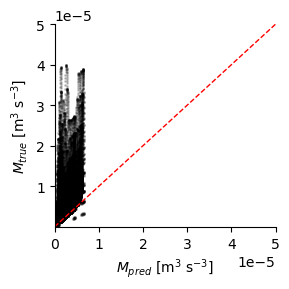

In [42]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(M_algebraic, y_val, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig("algebraic_mtrue_mpred.png", dpi=300)

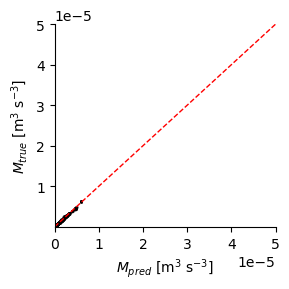

In [12]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(fcnn_prediction_val.detach().numpy(), y_val, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

# plt.savefig("interp_all_mtrue_mpred.png", dpi=300)

In [21]:
np.sqrt(np.mean((M_algebraic-y_val_1.detach().numpy())**2))

3.4280441139903626e-06

In [22]:
compute_rmse(mean_prediction_val, y_val_1)

tensor(4.4628e-06, grad_fn=<SqrtBackward0>)

NameError: name 'y_val' is not defined

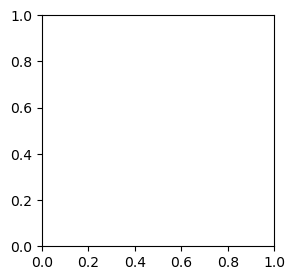

In [83]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(mean_prediction_val.detach().numpy(), y_val, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig("mean_mtrue_mpred.png", dpi=300)

In [28]:
config_1.n_time_steps = 432
config_1.n_time_steps_val = 432
config_2.n_time_steps = 432
config_2.n_time_steps_val = 432

In [29]:
delta_pred_1 = True
delta_pred_2 = False

if delta_pred_1:
    prediction_1 = recover_M_from_dM(
        dM=fcnn_prediction_val_1.detach().numpy(),
        n_time_steps=config_1.n_time_steps_val
    )
    truth_1 = recover_M_from_dM(
        dM=y_val_1.detach().numpy(),
        n_time_steps=config_1.n_time_steps_val
    )
else:
    prediction_1 = fcnn_prediction_val_1.detach().numpy()
    truth_1 = y_val_1.detach().numpy()

if delta_pred_2:
    prediction_2 = recover_M_from_dM(
        dM=fcnn_prediction_val_2.detach().numpy(),
        n_time_steps=config_2.n_time_steps_val
    )
    truth_2 = recover_M_from_dM(
        dM=y_val_2.detach().numpy(),
        n_time_steps=config_2.n_time_steps_val
    )
else:
    prediction_2 = fcnn_prediction_val_2.detach().numpy()
    truth_2 = y_val_2.detach().numpy()

In [30]:
config_1.n_time_steps_val

432

In [39]:
config_1.feature_names

['f', 'u_star', 'B', 'bl_tke', 'surf_mag', 'surf_angle', 'SS_bl', 'NN_bl', 'M']

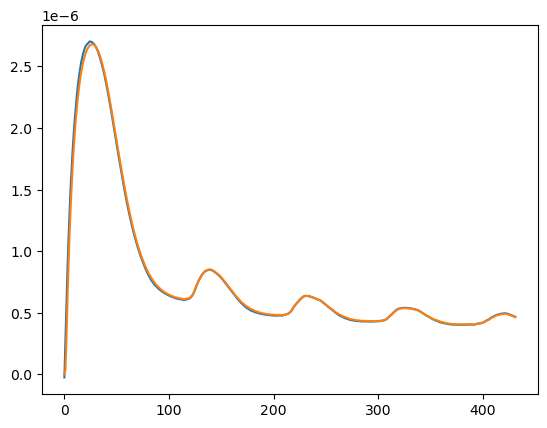

In [62]:
plt.plot((X_val_1[:,-1].detach().numpy()+fcnn_prediction_val_1.squeeze(-1).detach().numpy())[0:432])
plt.plot(truth_1[0:432])

(93312,)

/tmp/ipykernel_3622373/3891952771.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1,1,figsize=(10,4),tight_layout=True,sharex=True)


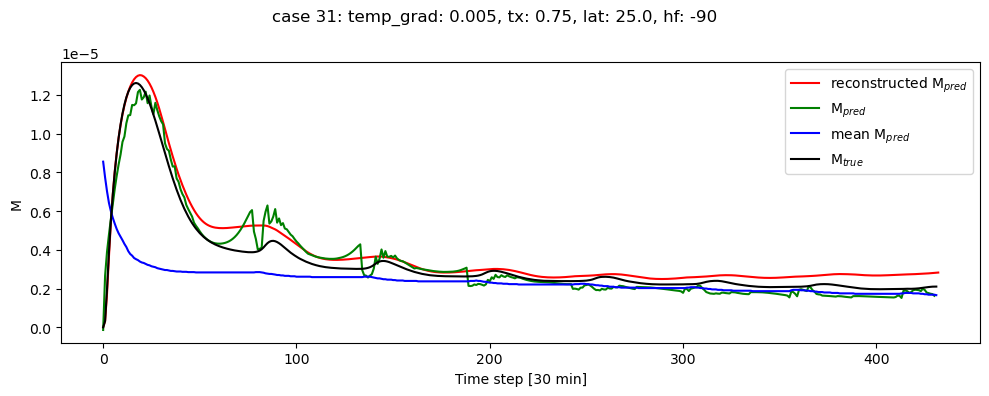

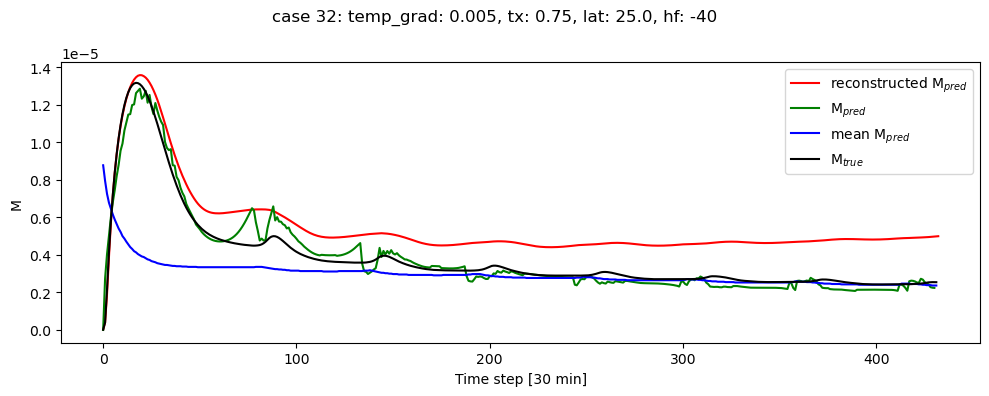

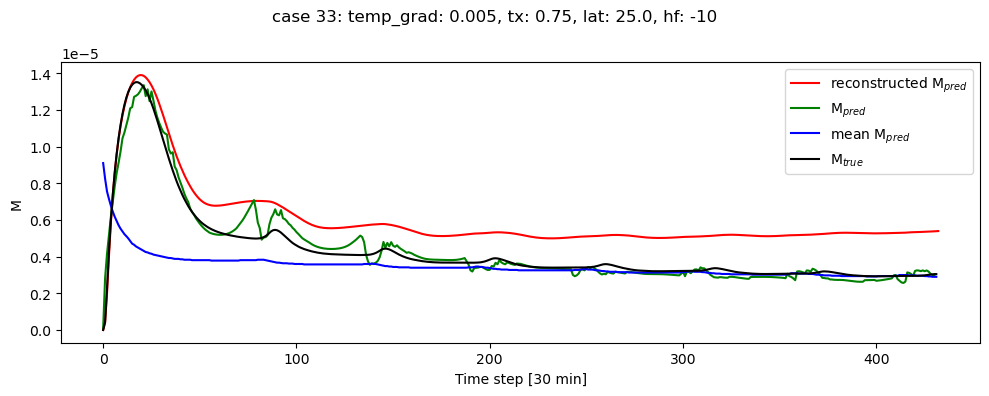

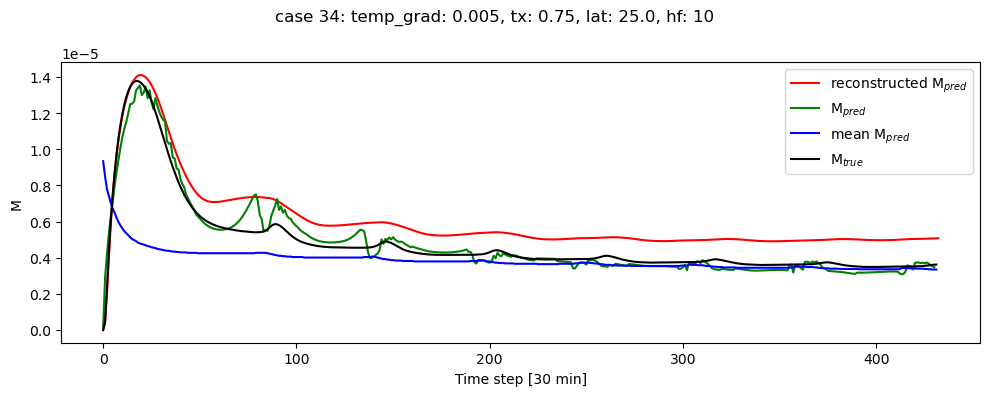

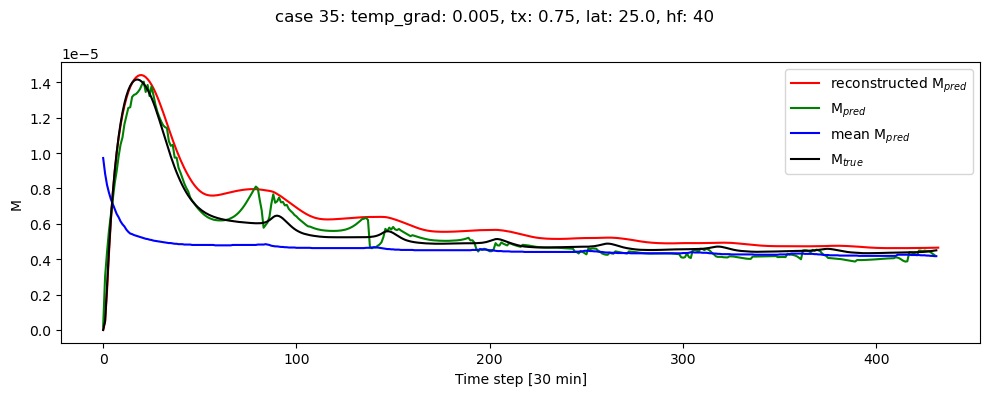

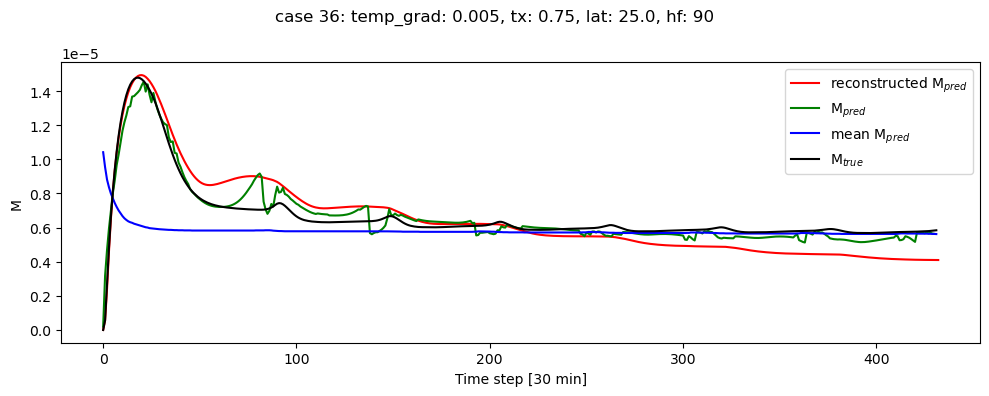

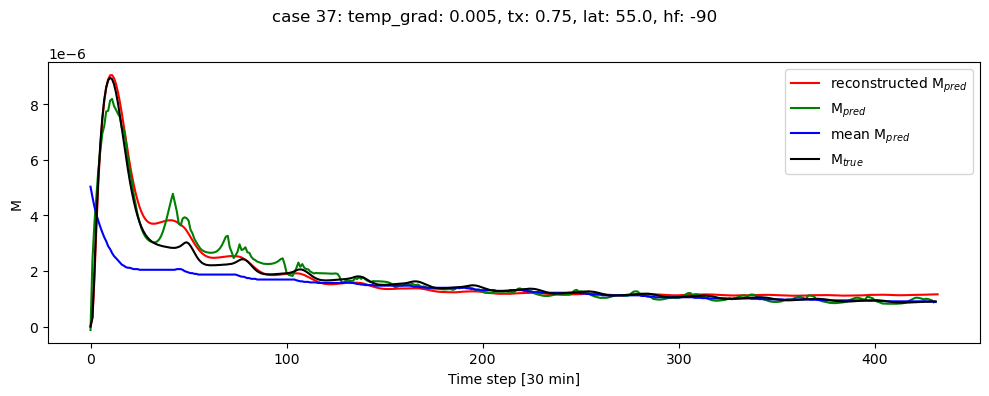

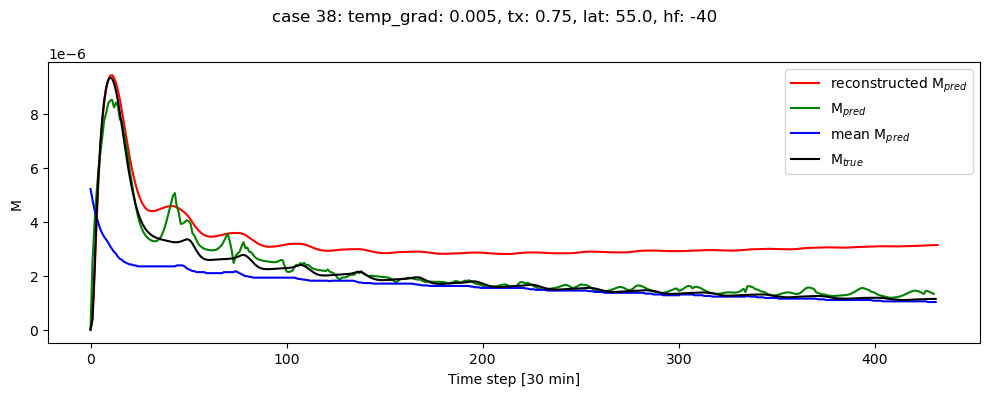

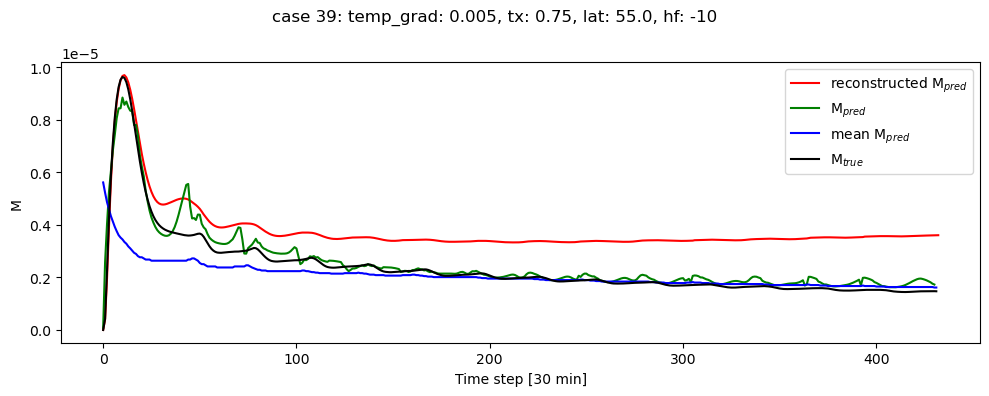

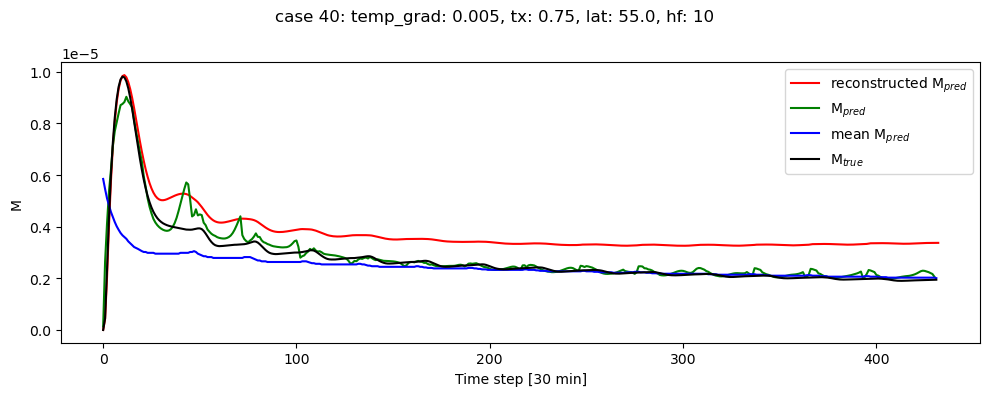

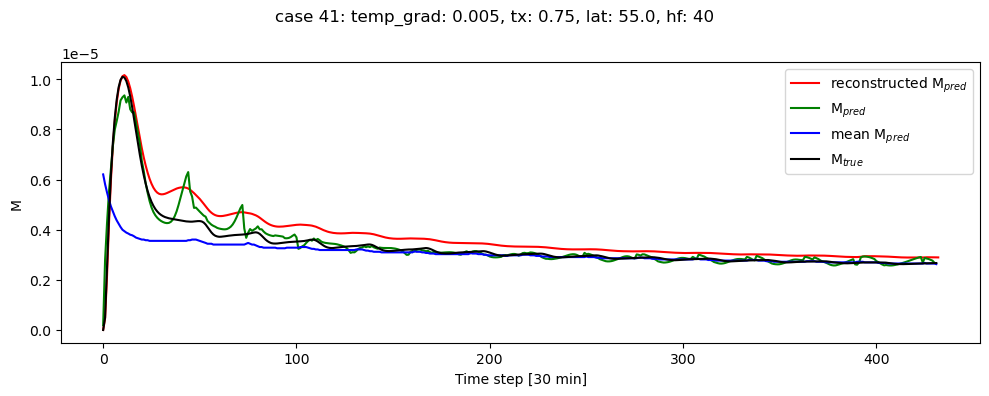

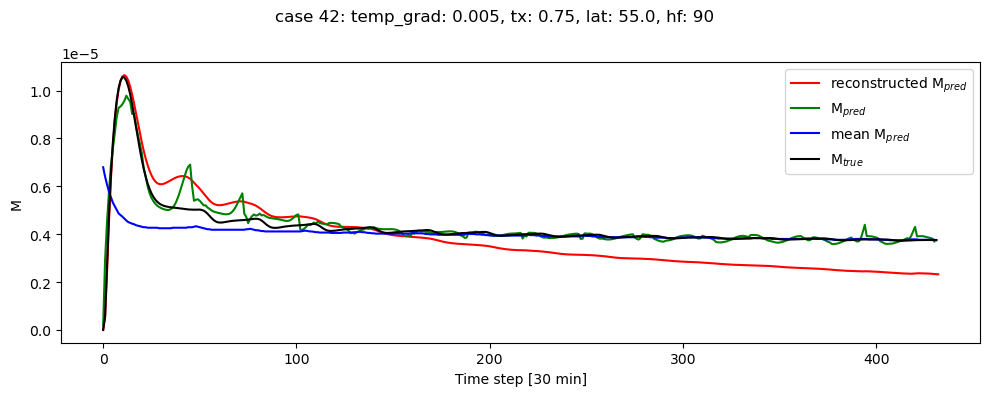

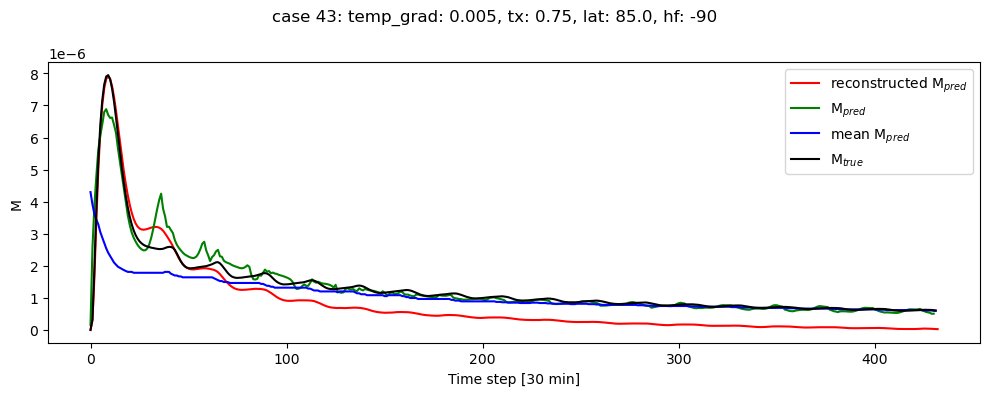

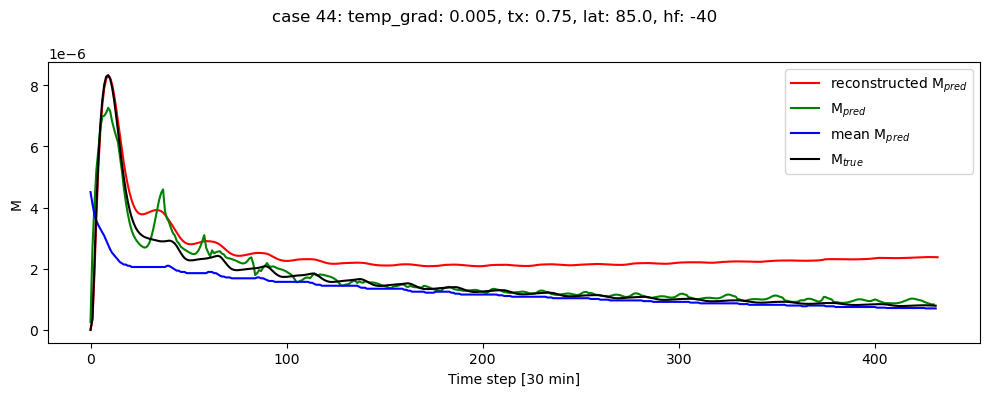

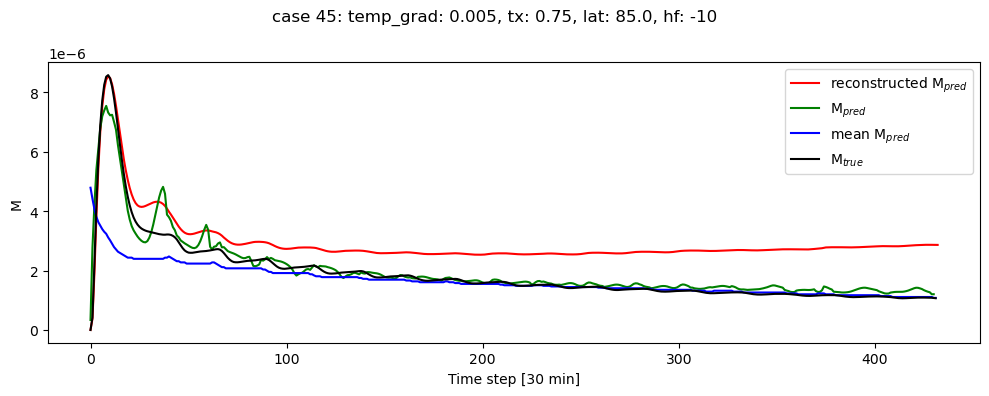

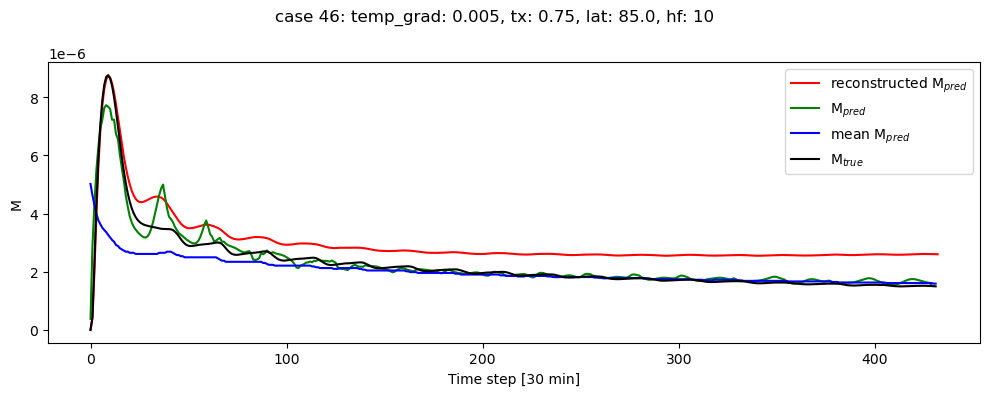

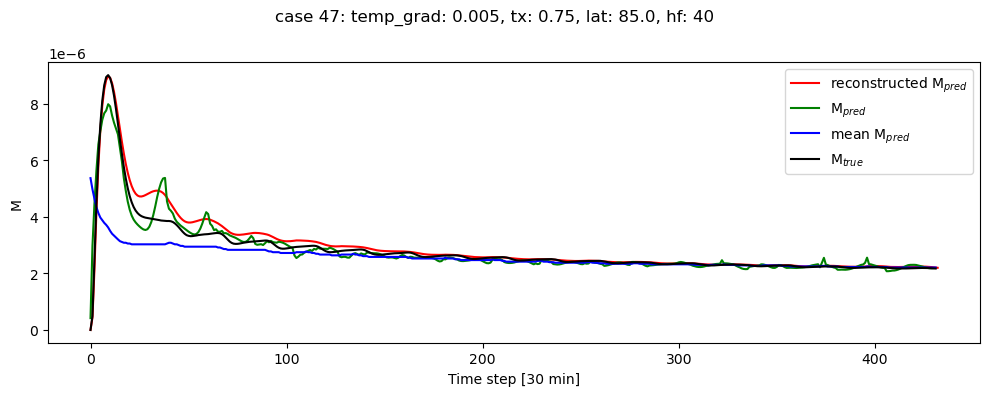

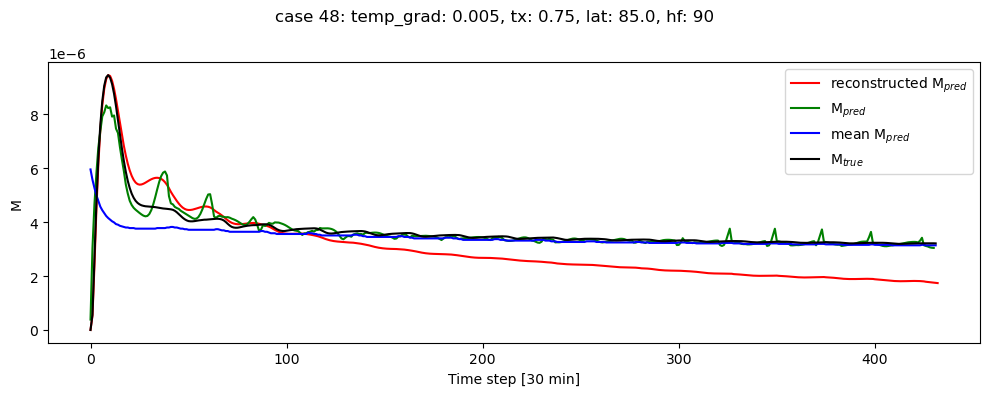

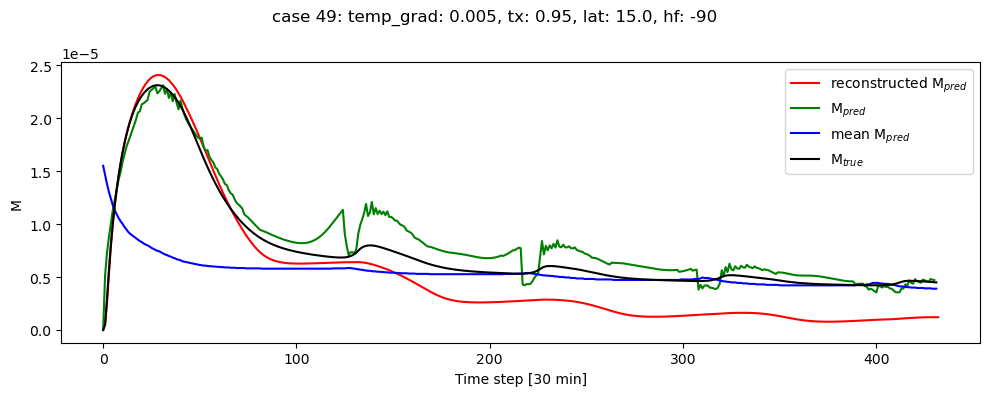

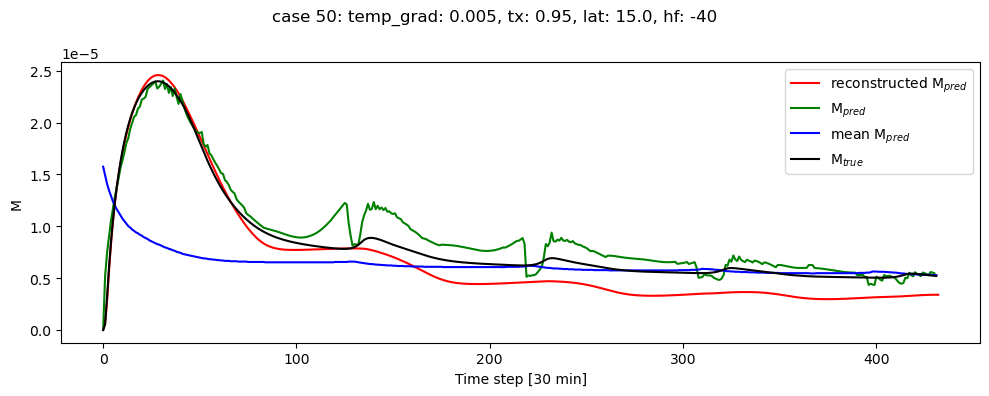

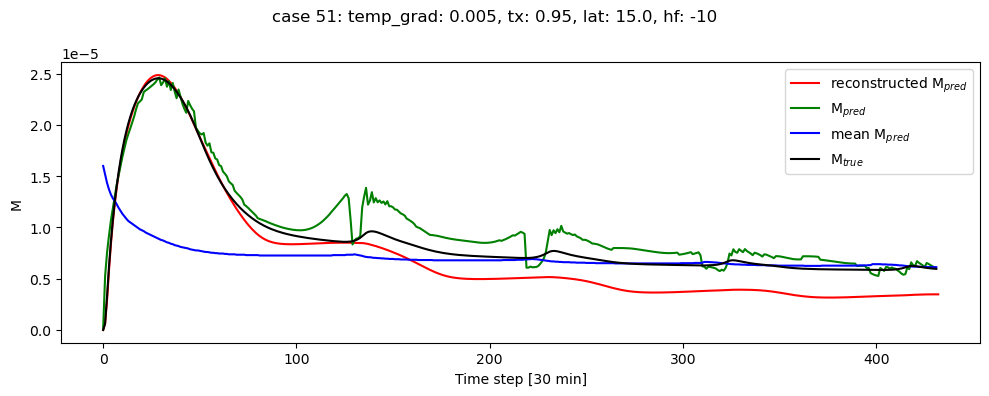

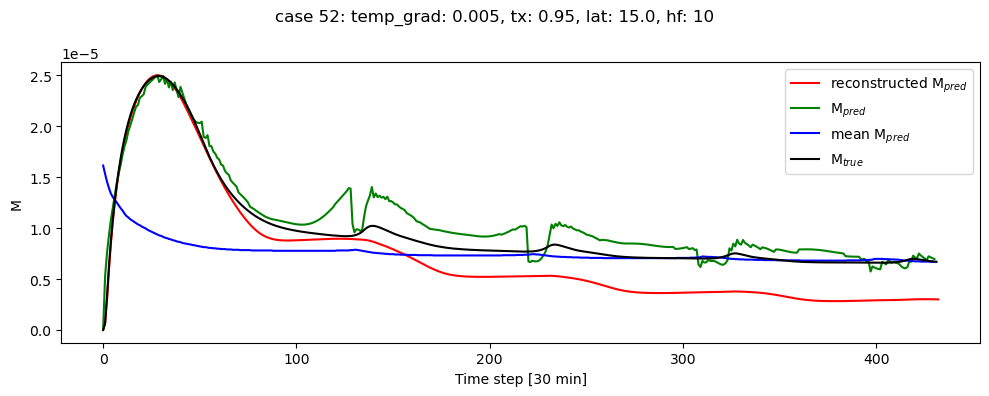

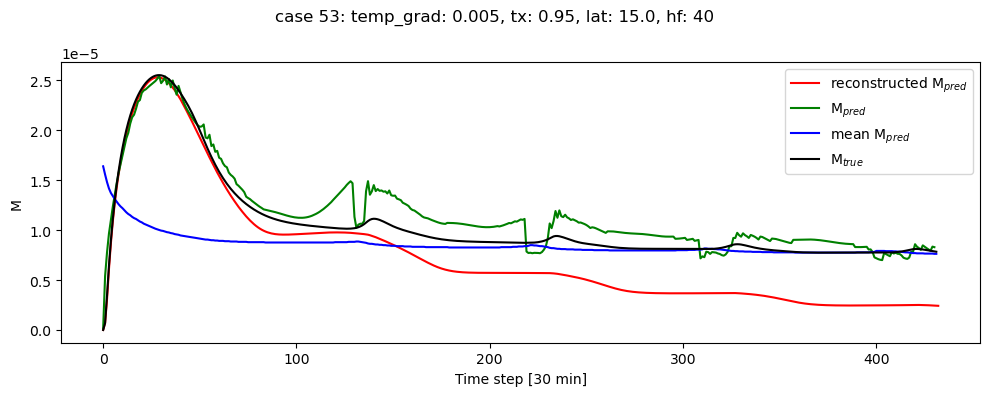

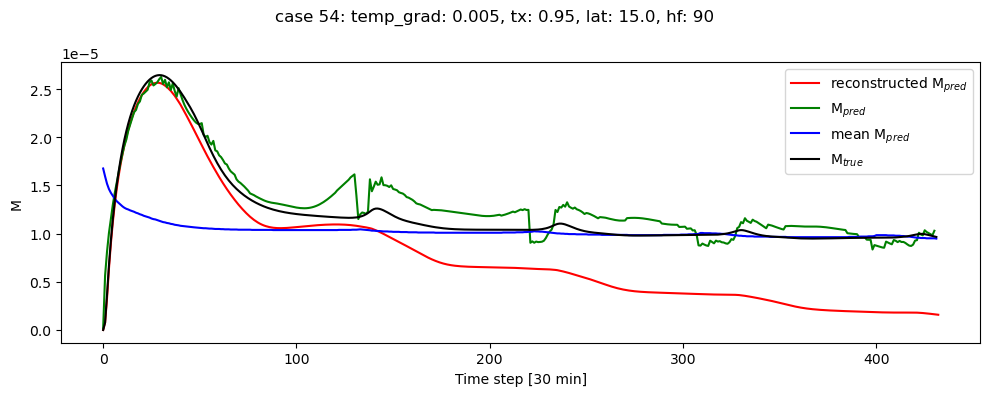

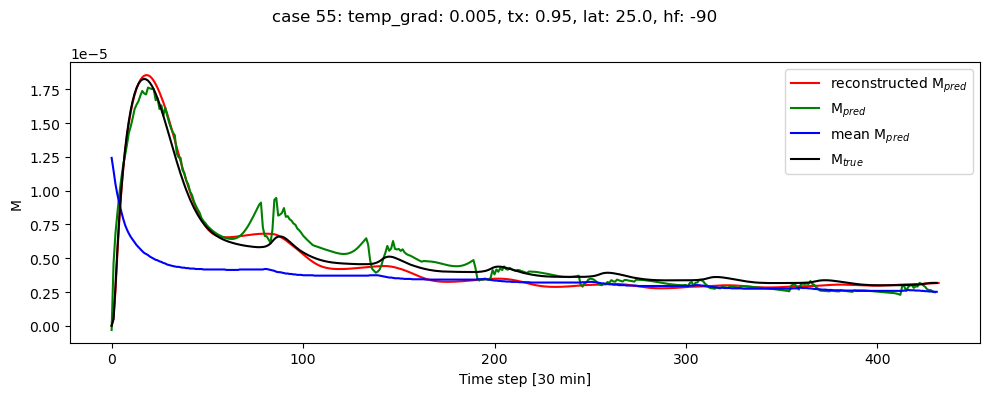

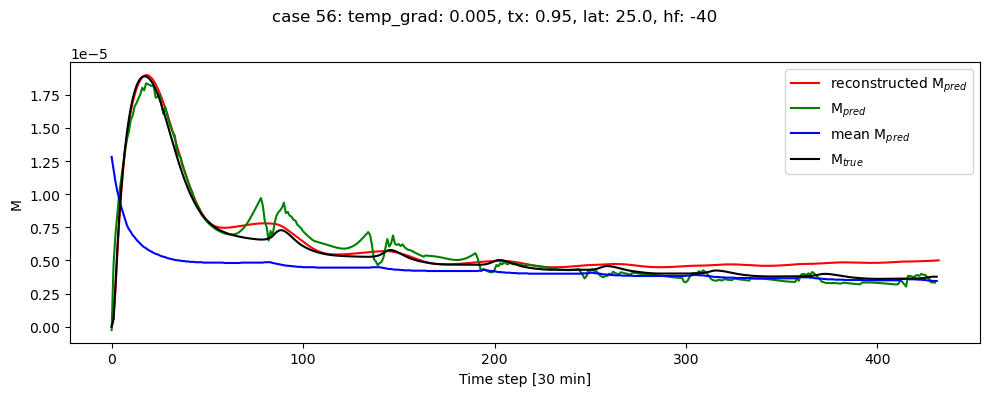

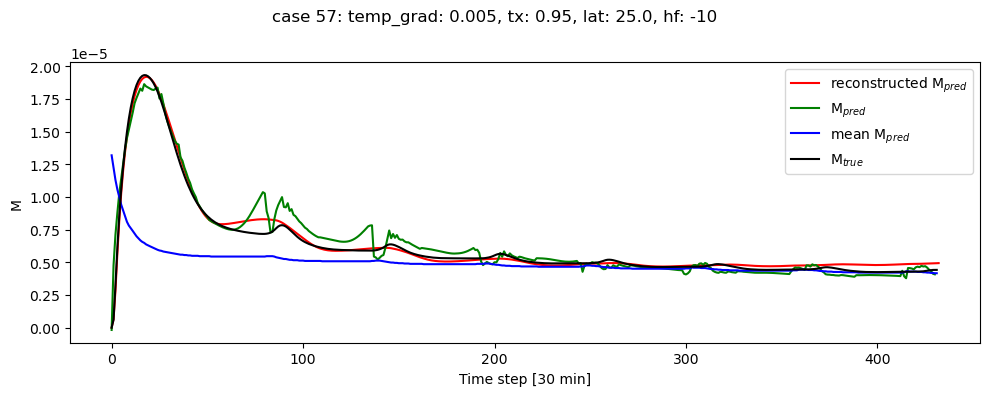

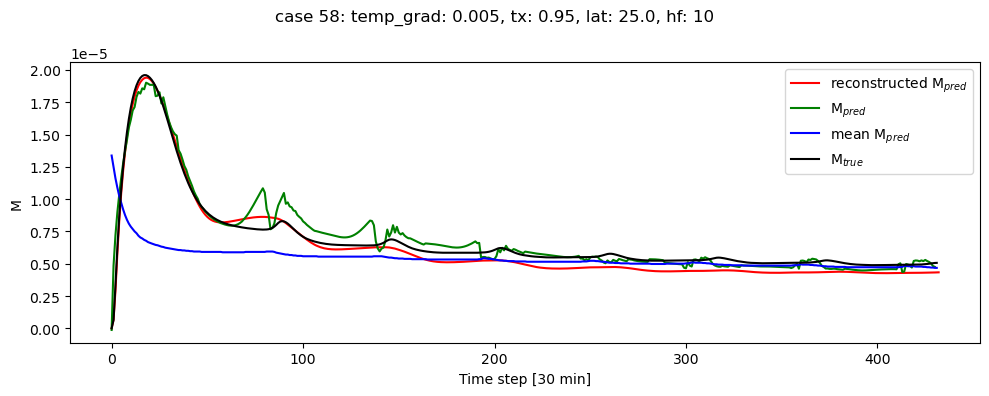

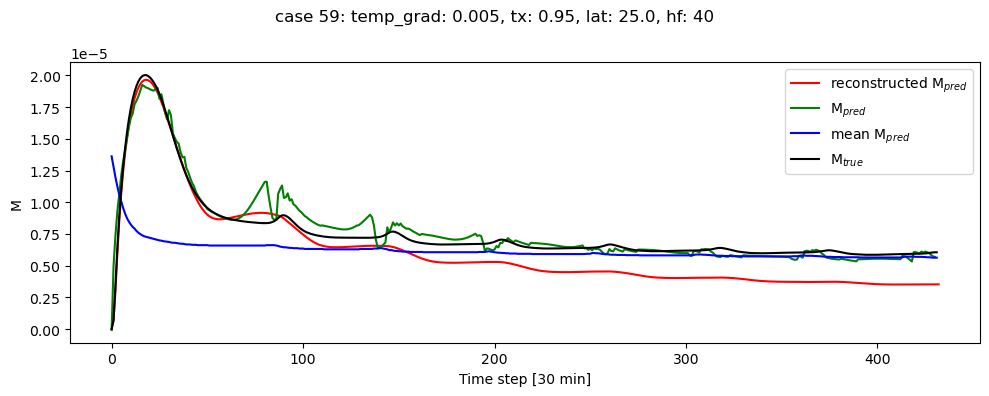

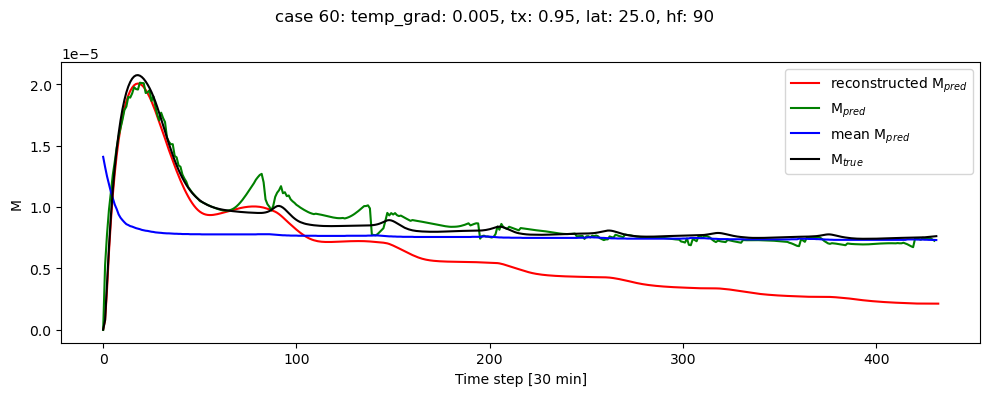

In [34]:
n_timesteps_1 = 433
n_timesteps = 432

for i in range(30,60):
    case_specs = gotm_validation_case_dict_1[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    fig, ax = plt.subplots(1,1,figsize=(10,4),tight_layout=True,sharex=True)
    plt.suptitle(f"case {i+1}: temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    ax.plot(prediction_1[n_timesteps_1*i:n_timesteps_1*(i+1)], label="reconstructed M$_{pred}$", color="red")
    ax.plot(prediction_2[n_timesteps*i+1:n_timesteps*(i+1)], label="M$_{pred}$", color="green")
    ax.plot(mean_prediction_val.detach().numpy()[n_timesteps*i:n_timesteps*(i+1)], label="mean M$_{pred}$", color="blue")
    # ax.plot(M_algebraic[n_timesteps*i:n_timesteps*(i+1)], label="algebraic M", color="green")
    ax.plot(truth_2[n_timesteps*i:n_timesteps*(i+1)], label="M$_{true}$", color="black")
    ax.set_xlabel("Time step [30 min]")
    ax.set_ylabel("M")
    ax.legend()

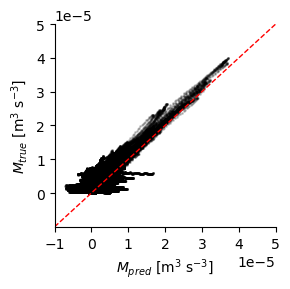

In [100]:
xs, ys = np.linspace(-1e-5, 5e-5, 1000), np.linspace(-1e-5, 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(prediction_1, truth_1, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([-1e-5, 0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(-1e-5, 5e-5)
ax.set_ylim(-1e-5, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig("M_pred_true_from_dM_N2_S2.png", dpi=300)

In [101]:
np.sqrt(np.mean((prediction_1-truth_1)**2))

2.5710717e-06

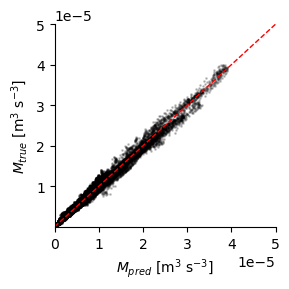

In [102]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(prediction_2, truth_2, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig("M_pred_true_from_state_N2_S2.png", dpi=300)

In [103]:
np.sqrt(np.mean((prediction_2-truth_2)**2))

4.2704934e-07